# ZeroER++ — block-filter full-data benchmarks (phase 2)

Takes each dataset's `<dataset>_block-filter` winner — best F1, tie-broken toward the smallest candidate set (`utils.front_trials`, delta 0.005) — and re-evaluates it on the **full data**, into sibling `<dataset>_block-filter_full` studies in the same `outputs/optuna.db`. Run `hyperparameter-tuning.ipynb` first.

## Setup

Generic runners in `tuning`, views in `reporting`; the objective + its knobs are declared below and **must match the tuning run** (enqueued configs replay through the same distributions).

In [1]:
from estimator import ZeroEREstimator, BlockFeatureCache
from data import DATASETS, DEFAULT_TUNE_FRACTION, load_data, embedding_models
from metrics import precision_recall_f1, blocking_recall
from tuning import retrain_all
from reporting import export, show_results

## Search space

Same `SPACE`/`SEED` as tuning; no budget needed — phase 2 only enqueues the existing best trials.

In [2]:
SEED = 0
EXPERIMENT = "block-filter"   # study names: <dataset>_block-filter[_full]
SPACE = {                     # blocking/filtering knobs only — the matcher stays stock ZeroER
    # "embedding_model" is added per dataset in the objective: every model
    # discovered under datasets/embeddings/<dataset>/ is a candidate.
    "top_k": (1, 10),                          # neighbours kept per entity
    "similarity_distance": ["cosine", "euclidean"],
}

## Objective

The per-experiment trial — declared here, not in `tuning`, so a new experiment is just a copy-and-tweak of this cell. It returns **F1 only** and carries its own `directions`, `experiment` (the study-name suffix) and `seed_trials` (per-model coverage guarantee); `make_objective` binds it to `SPACE`/`SEED` for the runners.

In [3]:
class BlockFilterObjective:
    """Single-objective trial: **max F1**, searching only blocking & filtering —
    k-NN candidate generation over precomputed LLM record embeddings. The
    ZeroER matcher runs stock (default ``c_bay``/``max_iter``), so any F1 gain
    is attributable to the blocking stage alone.

    One ``Data`` is loaded per instance and reused across trials. Blocking and
    feature generation run once per (model, distance) at the top_k upper bound
    and are sliced per trial (``BlockFeatureCache`` — k-NN lists are nested in
    top_k), so most trials cost only the EM. ``get_params`` *is* the search
    space; ``seed_trials`` guarantees every embedding model is visited at
    least once before TPE takes over.
    """
    directions = ["maximize"]                 # F1 only
    experiment = EXPERIMENT                   # -> study "<dataset>_block-filter"

    def __init__(self, dataset, space, seed=0, partition=True):
        self.dataset = dataset
        self.source_trial = None              # set by retrain_full to stamp each full trial
        self.data = load_data(dataset, partition=partition, seed=seed)
        self.attributes = DATASETS[dataset]["attributes"]
        models = embedding_models(dataset)
        if not models:
            raise FileNotFoundError(
                f"no precomputed embeddings under datasets/embeddings/{dataset}/")
        self.space = dict(space, embedding_model=models)   # per-dataset model list
        self.cache = BlockFeatureCache(dataset, self.data, self.attributes,
                                       k_max=space["top_k"][1], n_jobs=-1)
        frac = DATASETS[dataset].get("tune_fraction", DEFAULT_TUNE_FRACTION)
        scope = f"partition (frac={frac})" if partition else "full data"
        print(f"    {scope}: {self.data.num_of_entities_1}+{self.data.num_of_entities_2}"
              f" entities, {len(self.data.ground_truth)} matches, "
              f"{len(models)} embedding models", flush=True)

    def seed_trials(self):
        # one enqueued config per model (median top_k, cosine) — "go through
        # all the models" holds even under a sampled, non-grid budget
        mid_k = sum(self.space["top_k"]) // 2
        return [dict(embedding_model=m, top_k=mid_k, similarity_distance="cosine")
                for m in self.space["embedding_model"]]

    def get_params(self, trial):
        s = self.space
        return dict(
            embedding_model=trial.suggest_categorical("embedding_model", s["embedding_model"]),
            top_k=trial.suggest_int("top_k", *s["top_k"]),
            similarity_distance=trial.suggest_categorical("similarity_distance", s["similarity_distance"]),
        )

    def __call__(self, trial):
        p = self.get_params(trial)
        est = ZeroEREstimator(                        # stock ZeroER matcher
            blocker="precomputed", cache=self.cache,
            vectorizer=p["embedding_model"], top_k=p["top_k"],
            similarity_distance=p["similarity_distance"],
            attributes=self.attributes)
        graph = est.fit_predict(self.data)
        _, _, f1 = precision_recall_f1(graph, self.data)
        trial.set_user_attr("candset_size", est.candset_size)
        trial.set_user_attr("pair_completeness",
                            round(blocking_recall(est.blocks, self.data), 4))
        # one-time (model, distance) blocking+feature cost; repeated on hits
        trial.set_user_attr("blocking_seconds", est.blocking_seconds)
        trial.set_user_attr("em_seconds", round(est.matcher.em_time, 3))
        if self.source_trial is not None:
            trial.set_user_attr("source_trial", self.source_trial)
        return f1


def make_objective(dataset, partition=True):                 # factory the runners call per dataset
    return BlockFilterObjective(dataset, SPACE, SEED, partition=partition)

## Run phase 2 — retrain each front on the full data

Resumable: configs already retrained (stamped `source_trial`) are skipped.

In [ ]:
retrain_all(make_objective, seed=SEED)

## Results

This notebook produces the `full` studies; the `partition` ones are shown too when present in `optuna.db`. `export` regenerates the CSV views (`*_block-filter*.csv`) from the db.

=== partition: 5 Pareto-optimal configs across 5 dataset(s) ===


,dataset,phase,F1,candset_size,blocking_recall,embedding_model,top_k,similarity_distance,blocking_seconds,em_seconds
0,abt_buy,partition,0.1610,2961,0.1459,microsoft_harrier-oss-v1-27b,9,euclidean,25.270,0.578
1,amazon_googleproducts,partition,0.2593,4850,0.9769,Qwen_Qwen3-Embedding-8B,5,cosine,233.123,0.475
2,dblp_acm,partition,0.9925,688,0.9985,codefuse-ai_F2LLM-v2-4B,1,euclidean,16.050,0.483
3,dblp_scholar,partition,0.8421,19309,0.9658,Octen_Octen-Embedding-8B,1,cosine,1585.260,12.146
4,fodors_zagats,partition,1.0000,200,1.0000,nvidia_llama-embed-nemotron-8b,2,cosine,1.908,0.224


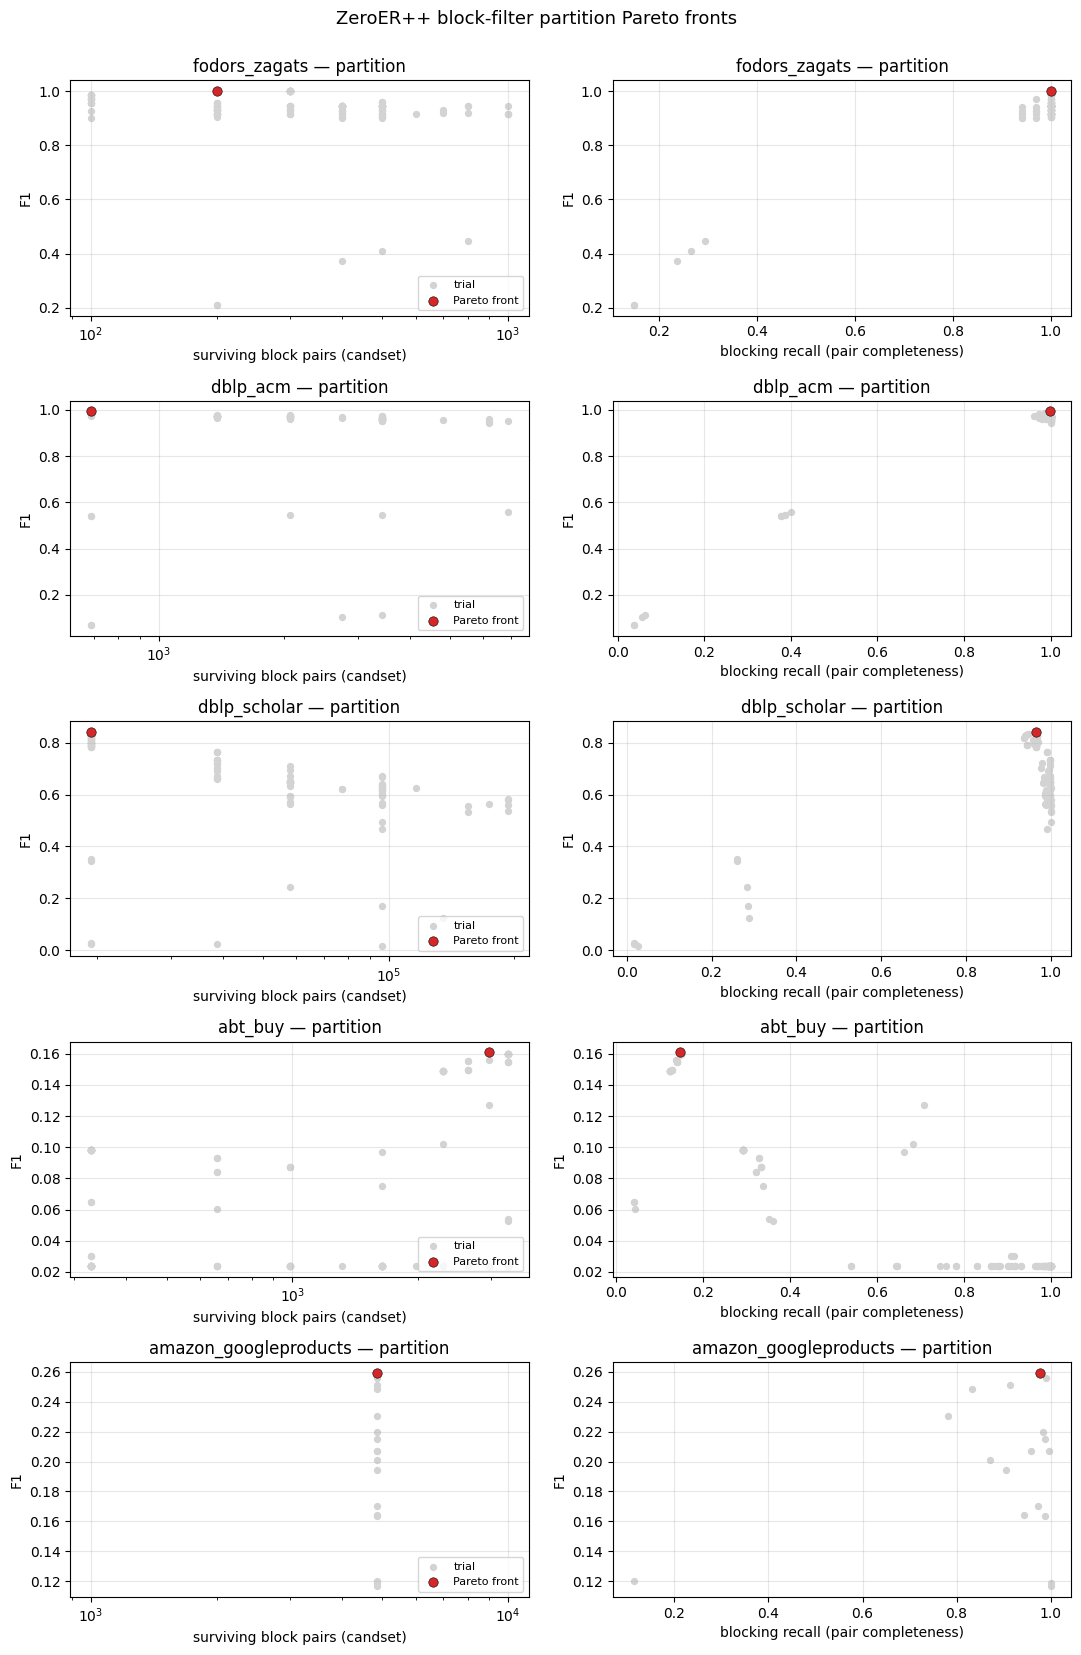

=== full: 5 Pareto-optimal configs across 5 dataset(s) ===


,dataset,phase,F1,candset_size,blocking_recall,embedding_model,top_k,similarity_distance,blocking_seconds,em_seconds,source_trial
0,abt_buy,full,0.0746,9828,0.0793,microsoft_harrier-oss-v1-27b,9,euclidean,28.539,1.001,114
1,amazon_googleproducts,full,0.1617,16130,0.9377,Qwen_Qwen3-Embedding-8B,5,cosine,985.161,10.253,2
2,dblp_acm,full,0.9883,2294,0.9928,codefuse-ai_F2LLM-v2-4B,1,euclidean,24.562,0.288,77
3,dblp_scholar,full,0.8203,64263,0.9663,Octen_Octen-Embedding-8B,1,cosine,474.222,11.051,30
4,fodors_zagats,full,0.9955,662,1.0000,nvidia_llama-embed-nemotron-8b,2,cosine,1.430,0.308,25


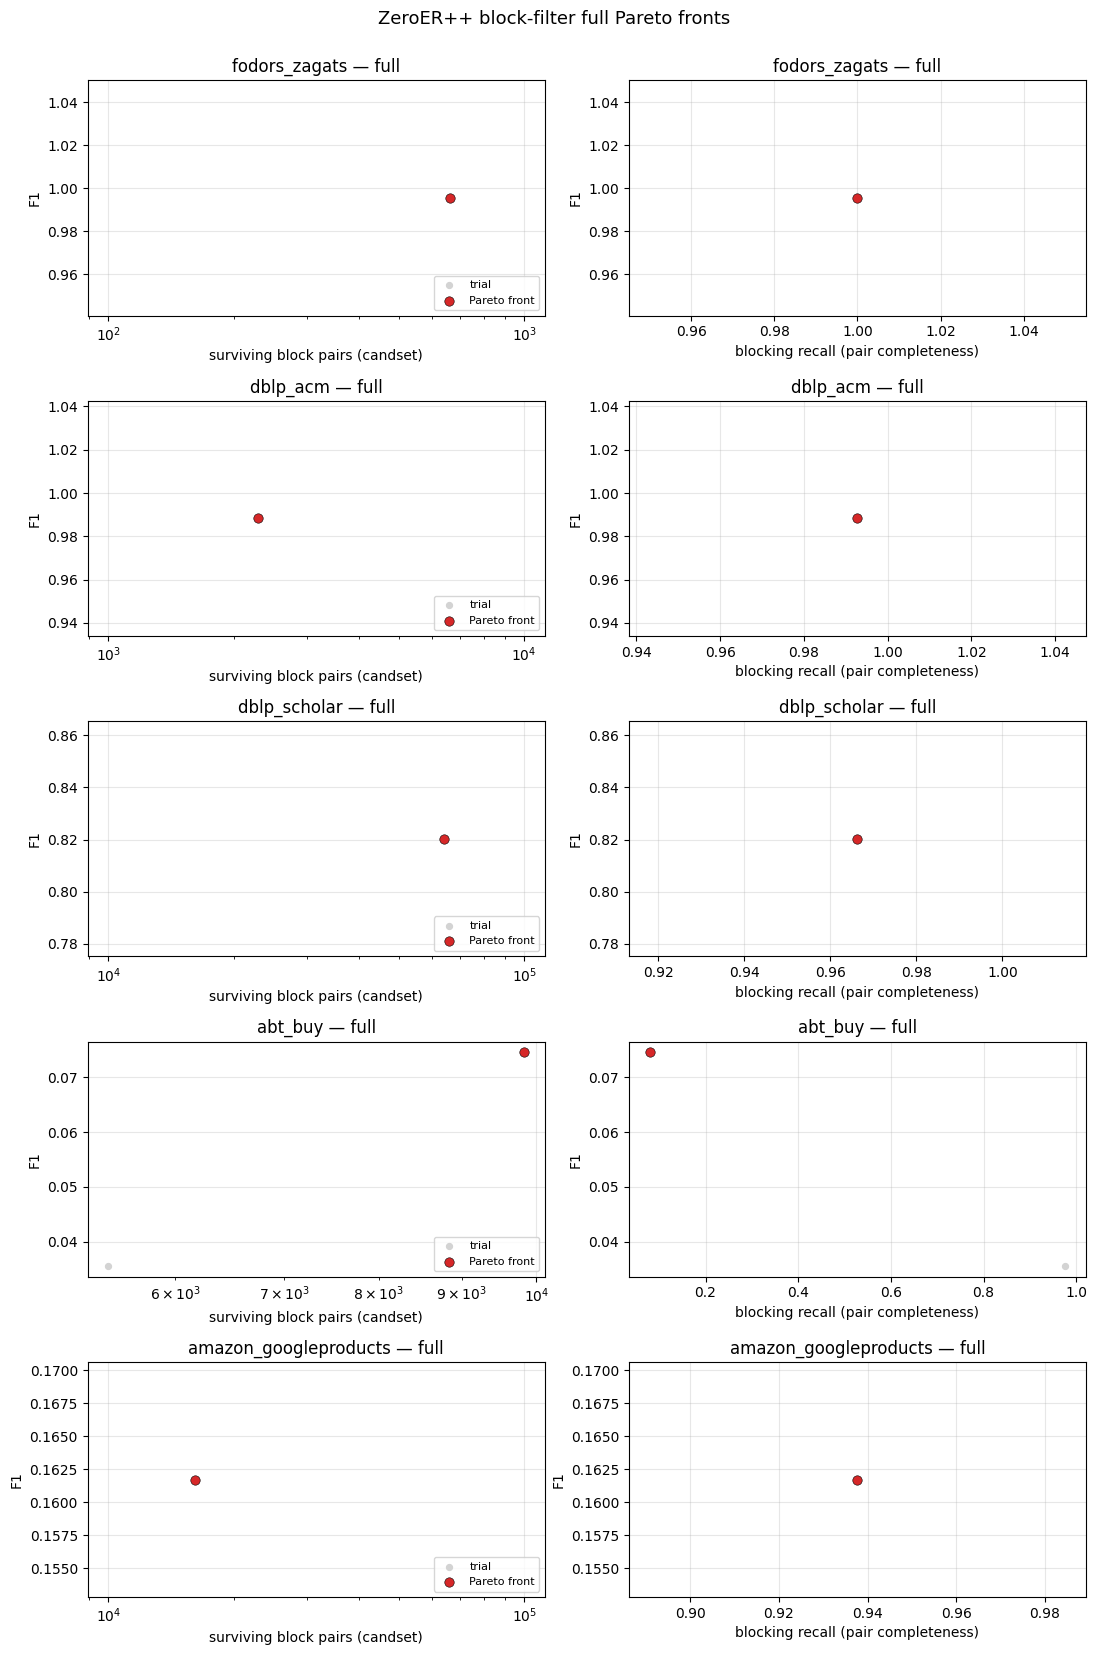

In [4]:
show_results(experiment=EXPERIMENT)

In [5]:
import sqlite3

conn = sqlite3.connect("./outputs/optuna.db")
cur = conn.cursor()

cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cur.fetchall())

[('studies',), ('version_info',), ('study_directions',), ('study_user_attributes',), ('study_system_attributes',), ('trials',), ('trial_user_attributes',), ('trial_system_attributes',), ('trial_params',), ('trial_values',), ('trial_intermediate_values',), ('trial_heartbeats',), ('alembic_version',)]


In [6]:
cur.execute("SELECT * FROM studies;")
print(cur.fetchall())

[(1, 'fodors_zagats_block-filter'), (2, 'dblp_acm_block-filter'), (3, 'dblp_scholar_block-filter'), (4, 'abt_buy_block-filter'), (5, 'amazon_googleproducts_block-filter'), (6, 'fodors_zagats_block-filter_full'), (7, 'dblp_acm_block-filter_full'), (8, 'dblp_scholar_block-filter_full'), (9, 'abt_buy_block-filter_full'), (10, 'amazon_googleproducts_block-filter_full')]
